In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

ENTITY = "simon-lacoste-julien"
PROJECT = "hyperscalenqs"

TAG_GROUPS = {
    "ising": {
        "QPS": "qps_ising",
        "minSR": "minsr_ising",
    },
    "heisenberg_chain": {
        "QPS": "qps_heisenberg_chain",
        "minSR": "minsr_heisenberg_chain",
    },
    "j1j2": {
        "QPS": "qps_j1j2",
        "minSR": "minsr_j1j2",
    },
}

METRICS = ["eval_rel_error_exact", "eval_V_score"]

PREFERRED_X = "_runtime"
X_LABEL = "Relative Time (Wall) [min]"
X_MAX_MINUTES = 30.0
TIME_GRID_MINUTES = np.linspace(0.0, X_MAX_MINUTES, 181)

daft_punk_palette = [
    "#981E1A",
    "#C44A18",
    "#E47A1E",
    "#F9DA2A",
    "#99B438",
    "#398D46",
    "#208AAE",
    "#1E4788",
    "#302E7F",
]

bright_daft_punk_palette = [    
    "#B9130D",    
    "#EF4804",    
    "#FF7A07",    
    "#FFDB12",    
    "#B7DC32",    
    "#39AC4B",    
    "#12A3D4",    
    "#154DA6",    
    "#2F2C9B",
]


METHOD_COLORS = {
    "QPS": "#2F2C9B",
    "minSR": "#39AC4B",
}

api_key = os.environ.get("WANDB_API_KEY")
if api_key:
    wandb.login(key=api_key, relogin=True)

api = wandb.Api(timeout=60)


def get_runs_with_tag(entity, project, tag):
    runs = list(
        api.runs(
            f"{entity}/{project}",
            filters={"tags": {"$in": [tag]}},
        )
    )
    print(f"Found {len(runs)} runs for tag '{tag}'")
    return runs


def run_history_dataframe(run, metrics, preferred_x="_runtime", shift_to_first_valid=True):
    keys = list(dict.fromkeys([preferred_x, "_step"] + list(metrics)))
    rows = list(run.scan_history(keys=keys))
    if not rows:
        return pd.DataFrame(columns=["x"] + list(metrics))

    df = pd.DataFrame(rows)

    x_col = preferred_x if preferred_x in df.columns and df[preferred_x].notna().any() else "_step"
    if x_col not in df.columns:
        return pd.DataFrame(columns=["x"] + list(metrics))

    out = df[[c for c in [x_col] + list(metrics) if c in df.columns]].copy()
    out = out.rename(columns={x_col: "x"})
    out = out.sort_values("x").drop_duplicates(subset=["x"], keep="last")

    if preferred_x == "_runtime":
        out["x"] = pd.to_numeric(out["x"], errors="coerce") / 60.0
    else:
        out["x"] = pd.to_numeric(out["x"], errors="coerce")

    for m in metrics:
        if m not in out.columns:
            out[m] = np.nan
        out[m] = pd.to_numeric(out[m], errors="coerce")

    out = out.dropna(subset=["x"]).reset_index(drop=True)

    # Shift each run so time zero is the first valid metric point
    if shift_to_first_valid and not out.empty:
        valid_mask = out[list(metrics)].notna().any(axis=1)
        if valid_mask.any():
            x0 = out.loc[valid_mask, "x"].iloc[0]
            out["x"] = out["x"] - x0
            out = out[out["x"] >= 0].reset_index(drop=True)

    return out


def align_run_to_time_grid(df, metrics, time_grid):
    if df.empty:
        out = pd.DataFrame({"x": time_grid})
        for m in metrics:
            out[m] = np.nan
        return out

    df = df.sort_values("x").copy()
    df = df[df["x"] <= time_grid[-1]]

    aligned = pd.DataFrame({"x": time_grid})
    aligned = pd.merge_asof(
        aligned,
        df,
        on="x",
        direction="backward",
    )

    for m in metrics:
        if m not in aligned.columns:
            aligned[m] = np.nan
        aligned[m] = aligned[m].ffill()

    return aligned


def iqm_stats(values_1d, min_keep=2):
    vals = np.sort(values_1d[~np.isnan(values_1d)])
    n = vals.size

    if n == 0:
        return np.nan, np.nan, np.nan, 0

    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)

    # IQM = mean of middle 50%
    lo = int(np.floor(0.25 * n))
    hi = int(np.ceil(0.75 * n))
    kept = vals[lo:hi]

    if kept.size < min_keep:
        kept = vals

    iqm = np.mean(kept)
    return iqm, q1, q3, kept.size


def aggregate_tag_runs(runs, metrics, preferred_x="_runtime", time_grid=None):
    if time_grid is None:
        time_grid = TIME_GRID_MINUTES

    histories = []
    run_names = []

    for run in runs:
        df = run_history_dataframe(
            run,
            metrics,
            preferred_x=preferred_x,
            shift_to_first_valid=True,
        )
        if df.empty:
            continue
        aligned = align_run_to_time_grid(df, metrics, time_grid)
        histories.append(aligned)
        run_names.append(run.name)

    if not histories:
        return {}

    out = {}
    for metric in metrics:
        values = np.stack([h[metric].to_numpy(dtype=float) for h in histories], axis=0)

        iqm_mean = np.full(values.shape[1], np.nan, dtype=float)
        q1_arr = np.full(values.shape[1], np.nan, dtype=float)
        q3_arr = np.full(values.shape[1], np.nan, dtype=float)
        counts = np.zeros(values.shape[1], dtype=float)

        for t in range(values.shape[1]):
            m, q1, q3, c = iqm_stats(values[:, t], min_keep=2)
            iqm_mean[t] = m
            q1_arr[t] = q1
            q3_arr[t] = q3
            counts[t] = c

        summary = pd.DataFrame({
            "x": time_grid,
            "mean": iqm_mean,   # keep the same name so the rest of the code stays simple
            "q1": q1_arr,
            "q3": q3_arr,
            "count": counts,
        })

        # Forward-fill with last valid value
        summary["mean"] = summary["mean"].ffill()
        summary["q1"] = summary["q1"].ffill()
        summary["q3"] = summary["q3"].ffill()
        summary["count"] = summary["count"].replace(0, np.nan).ffill()

        # Keep only points after the first valid observation
        summary = summary[summary["mean"].notna()].reset_index(drop=True)

        out[metric] = summary

    print("Included runs:", run_names)
    return out


def build_problem_aggregate(problem_name):
    methods = TAG_GROUPS[problem_name]
    problem_agg = {}
    print(f"\\n=== {problem_name} ===")
    for method_name, tag in methods.items():
        runs = get_runs_with_tag(ENTITY, PROJECT, tag)
        problem_agg[method_name] = aggregate_tag_runs(
            runs=runs,
            metrics=METRICS,
            preferred_x=PREFERRED_X,
            time_grid=TIME_GRID_MINUTES,
        )
    return problem_agg

In [48]:
from pathlib import Path

# Good size for two plots side by side in NeurIPS
FIG_W = 4.5
FIG_H = 3.5

OUTPUT_DIR = Path("neurips_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

def plot_metric(problem_name, problem_agg, metric, yscale=None, save_pdf=True, show=True):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    any_plotted = False
    for method_name, metric_map in problem_agg.items():
        if metric not in metric_map:
            continue
        df = metric_map[metric]
        if df.empty:
            continue

        df = df.copy()
        df["mean"] = df["mean"].ffill()
        df["q1"] = df["q1"].ffill()
        df["q3"] = df["q3"].ffill()

        df = df.dropna(subset=["mean"])
        if df.empty:
            continue

        x = df["x"].to_numpy(dtype=float)
        y = df["mean"].to_numpy(dtype=float)
        q1 = df["q1"].to_numpy(dtype=float)
        q3 = df["q3"].to_numpy(dtype=float)

        color = METHOD_COLORS.get(method_name, None)

        ax.plot(x, y, label=method_name, color=color, linewidth=2)
        ax.fill_between(x, q1, q3, color=color, alpha=0.2)
        any_plotted = True

    if not any_plotted:
        plt.close(fig)
        print(f"No data for {problem_name} / {metric}")
        return

    pretty_metric = {
        "eval_rel_error_exact": "Eval Relative Error",
        "eval_V_score": "Eval V-score",
    }.get(metric, metric)

    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(pretty_metric)
    ax.set_xlim(0, X_MAX_MINUTES)

    if yscale is not None:
        ax.set_yscale(yscale)

    ax.grid(True, alpha=0.3)

    # Horizontal legend below the plot
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=2,
        frameon=False,
        columnspacing=1.2,
        handlelength=2.0,
    )

    # Leave space at the bottom for the legend
    fig.tight_layout(rect=[0, 0.08, 1, 1], pad=0.2)

    pdf_path = OUTPUT_DIR / f"{problem_name}_{metric}.pdf"
    if save_pdf:
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight", pad_inches=0.02)
        print(f"Saved: {pdf_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


def export_problem_plots(problem_name, problem_agg):
    plot_metric(
        problem_name,
        problem_agg,
        "eval_rel_error_exact",
        yscale="log",
        save_pdf=True,
        show=True,
    )
    plot_metric(
        problem_name,
        problem_agg,
        "eval_V_score",
        yscale="log",
        save_pdf=True,
        show=True,
    )

\n=== ising ===
Found 10 runs for tag 'qps_ising'
Included runs: ['qps_ising_seed_48', 'qps_ising_seed_49', 'qps_ising_seed_44', 'qps_ising_seed_46', 'qps_ising_seed_45', 'qps_ising_seed_51', 'qps_ising_seed_47', 'qps_ising_seed_50', 'qps_ising_seed_43', 'qps_ising_seed_42']
Found 10 runs for tag 'minsr_ising'
Included runs: ['minsr_ising_seed_44', 'minsr_ising_seed_45', 'minsr_ising_seed_46', 'minsr_ising_seed_47', 'minsr_ising_seed_42', 'minsr_ising_seed_48', 'minsr_ising_seed_43', 'minsr_ising_seed_49', 'minsr_ising_seed_50', 'minsr_ising_seed_51']
Saved: neurips_plots/ising_eval_rel_error_exact.pdf


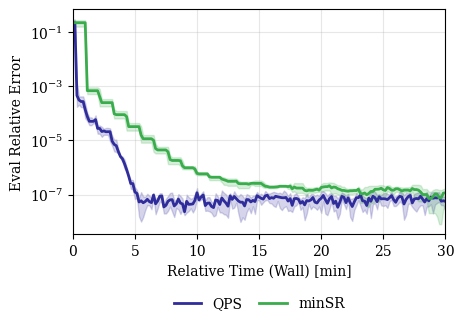

Saved: neurips_plots/ising_eval_V_score.pdf


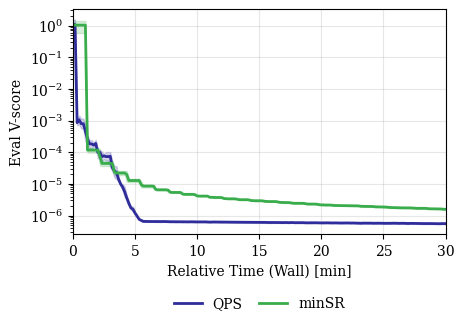

In [49]:
ising_agg = build_problem_aggregate("ising")
plot_metric("ising", ising_agg, "eval_rel_error_exact", yscale="log")
plot_metric("ising", ising_agg, "eval_V_score", yscale="log")

\n=== heisenberg_chain ===
Found 8 runs for tag 'qps_heisenberg_chain'
Included runs: ['qps_heisenberg_chain_seed_45', 'qps_heisenberg_chain_seed_46', 'qps_heisenberg_chain_seed_47', 'qps_heisenberg_chain_seed_42', 'qps_heisenberg_chain_seed_50', 'qps_heisenberg_chain_seed_49', 'qps_heisenberg_chain_seed_44', 'qps_heisenberg_chain_seed_43']
Found 9 runs for tag 'minsr_heisenberg_chain'
Included runs: ['minsr_heisenberg_chain_seed_45', 'minsr_heisenberg_chain_seed_44', 'minsr_heisenberg_chain_seed_43', 'minsr_heisenberg_chain_seed_51', 'minsr_heisenberg_chain_seed_50', 'minsr_heisenberg_chain_seed_46', 'minsr_heisenberg_chain_seed_47', 'minsr_heisenberg_chain_seed_48', 'minsr_heisenberg_chain_seed_42']
Saved: neurips_plots/heisenberg_chain_eval_rel_error_exact.pdf


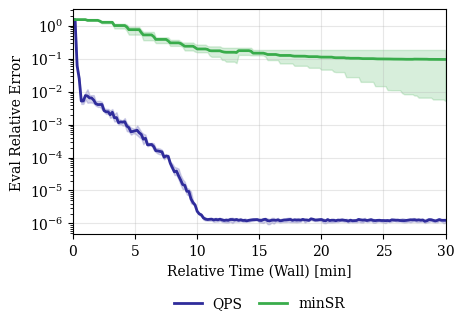

Saved: neurips_plots/heisenberg_chain_eval_V_score.pdf


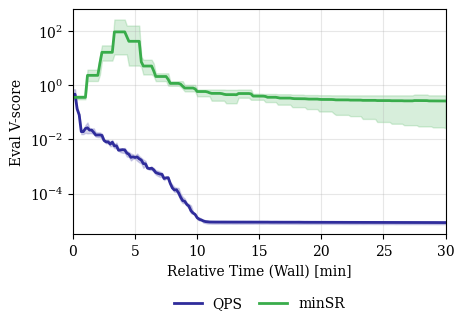

In [50]:
heisenberg_agg = build_problem_aggregate("heisenberg_chain")
plot_metric("heisenberg_chain", heisenberg_agg, "eval_rel_error_exact", yscale="log")
plot_metric("heisenberg_chain", heisenberg_agg, "eval_V_score", yscale="log")

\n=== j1j2 ===
Found 9 runs for tag 'qps_j1j2'
Included runs: ['qps_j1j2_seed_46', 'qps_j1j2_seed_43', 'qps_j1j2_seed_47', 'qps_j1j2_seed_50', 'qps_j1j2_seed_48', 'qps_j1j2_seed_49', 'qps_j1j2_seed_44', 'qps_j1j2_seed_45', 'qps_j1j2_seed_51']
Found 9 runs for tag 'minsr_j1j2'
Included runs: ['minsr_j1j2_seed_45', 'minsr_j1j2_seed_46', 'minsr_j1j2_seed_44', 'minsr_j1j2_seed_43', 'minsr_j1j2_seed_47', 'minsr_j1j2_seed_48', 'minsr_j1j2_seed_49', 'minsr_j1j2_seed_50', 'minsr_j1j2_seed_51']
Saved: neurips_plots/j1j2_eval_rel_error_exact.pdf


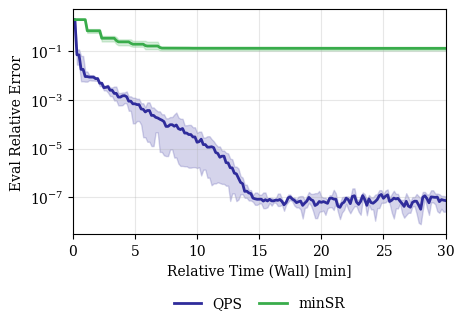

Saved: neurips_plots/j1j2_eval_V_score.pdf


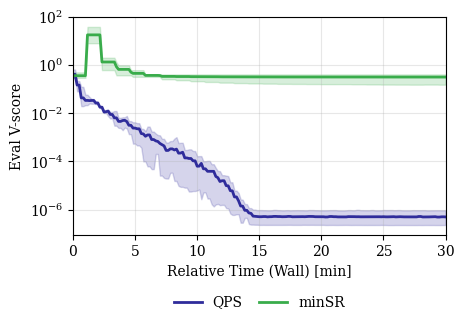

In [51]:
j1j2_agg = build_problem_aggregate("j1j2")
plot_metric("j1j2", j1j2_agg, "eval_rel_error_exact", yscale="log")
plot_metric("j1j2", j1j2_agg, "eval_V_score", yscale="log")